# Comparison of Data Simulated from Regression Models with Real Crash Data


Task 1: Get acquainted with the code. The existing code visualizes simulated data generated from Poisson and negative binomial distributions.

Experiment with the parameters to grasp their influence on the generated crash counts.

The general functional form used in these models is

$\lambda = length\times ADT^{B_1}\times e^{B_2\times ADT + Intercept}$

this is exactly the same as

$\lambda = length\times e^{B_1 \times log(ADT) + B_2\times ADT + Intercept}$

The models assume the length of all the segments is 1 for visualization purposes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

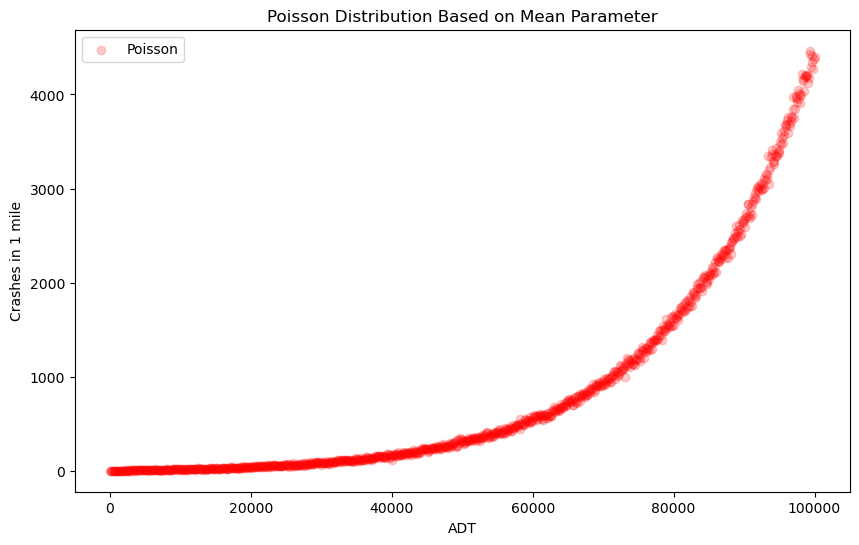

In [86]:
def plot_poisson(intercept=-7, beta2=0.00004, beta1=0.99, x_values=np.linspace(1, 100000, 1000)):
    # Set seed for reproducibility
    
    # Calculate the mean of the poisson distribution based on the model
    # Use a log link function
    lambda_poisson = np.exp(intercept + beta1*np.log(x_values) + beta2 * x_values)

    # Generate counts from Poisson distribution based on the mean parameter
    poisson_counts = np.random.poisson(lambda_poisson, size=len(x_values))
    plt.scatter(x_values, poisson_counts, label='Poisson', alpha=0.2, color="red")


# Plotting
plt.figure(figsize=(10, 6))
np.random.seed(42)
plot_poisson()
plt.xlabel('ADT')
plt.ylabel('Crashes in 1 mile')
plt.title('Poisson Distribution Based on Mean Parameter')
plt.legend()
plt.show()

Extracted 1000 data points.


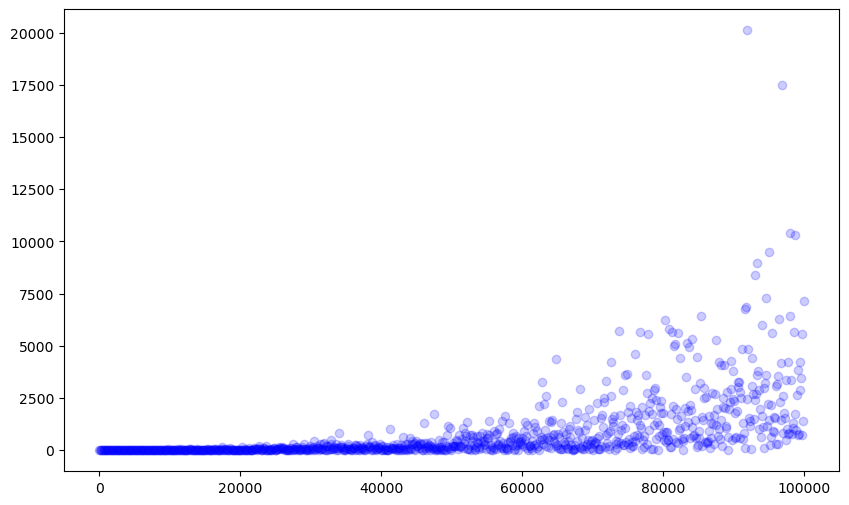

In [87]:
def plot_negative_binomial(intercept=-7, beta2=0.00004, beta1=0.99, k=0.0001, x_values=np.linspace(1, 100000, 1000)):
    
    # Calculate the mean of the negative binomial distribution based on the model
    # Use a log link function
    mean_nb = np.exp(intercept + beta1*np.log(x_values) + beta2 * x_values)

    # Parameters for Negative Binomial distribution
    negative_binomial_r = 1/k  # Number of successes required (1/k where k is the value estimated by R's GLM.NB)
    negative_binomial_p = negative_binomial_r / (negative_binomial_r + mean_nb)  # Probability of success

    # Generate counts from Negative Binomial distribution based on the updated mean
    negative_binomial_counts_updated = np.random.negative_binomial(negative_binomial_r, negative_binomial_p, size=len(x_values))
    plt.scatter(x_values, negative_binomial_counts_updated, label='Negative Binomial', alpha=0.2, color="blue")
    
    return negative_binomial_counts_updated

plt.figure(figsize=(10, 6))
np.random.seed(42)

# 1. CALL and ASSIGN: This extracts the array and stores it in nb_counts
nb_counts = plot_negative_binomial(k=1)

# Now 'nb_counts' is a standard NumPy array you can use outside the function
print(f"Extracted {len(nb_counts)} data points.")

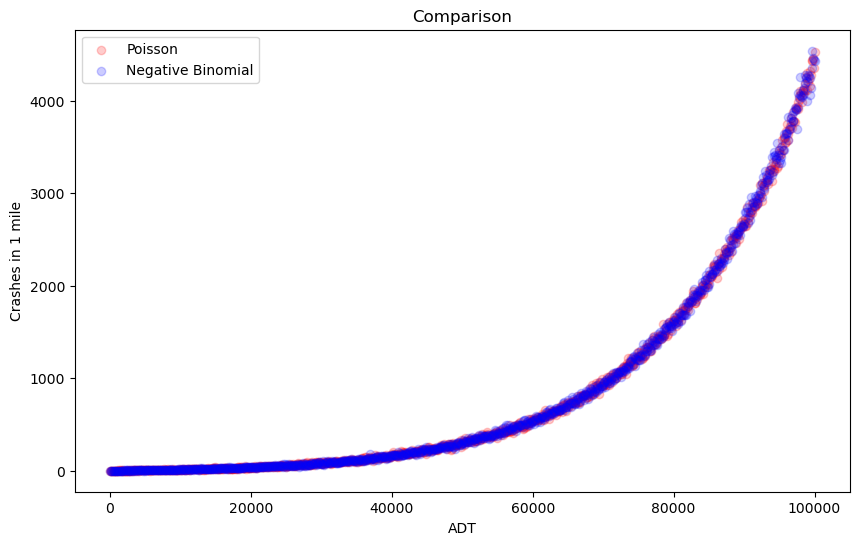

In [88]:
# Plotting
plt.figure(figsize=(10, 6))
plot_poisson()
plot_negative_binomial()
plt.xlabel('ADT')
plt.ylabel('Crashes in 1 mile')
plt.title('Comparison')
plt.legend()
plt.show()

Task 2: Select a facility type from the list provided. Load the data and update the parameters of the models to those obtained with the regression model.

Compare the simulated vs the real data for the negative binomial and poisson model

In [55]:
import os
os.getcwd()

'/Users/zorakramer/Safety/AssgnInClass/CE_C265_SPF_Exercise_v2026'

In [56]:
real_data = pd.read_csv("H13_FF_model_offset_data_reduced.csv")


In [57]:
real_adt_values = np.array(real_data["SPFH_ADT_AMT"])
real_crash_counts = np.array(real_data["CUS_N_COLL"])
real_length_values = np.array(real_data["SPFH_LENGTH_MILES_AMT"])
model_predictions = np.array(real_data["predictions"])

In [58]:
model_predictions

array([0.29486897, 0.2993713 , 0.28727702, ..., 0.63857521, 0.53390975,
       7.76764826], shape=(18733,))

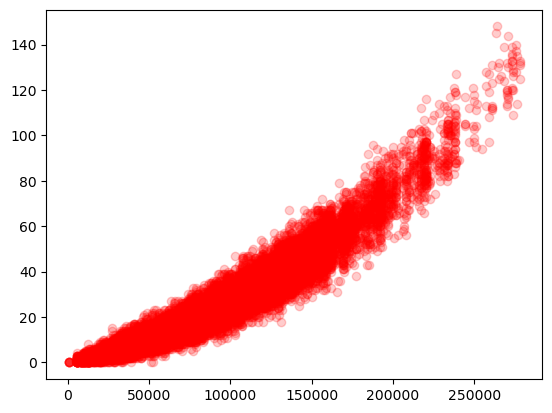

In [90]:


plot_poisson(intercept=-10.31864312, beta2=2.37986E-06, beta1=1.160463401, x_values=real_adt_values)


array([  4,  11,   4, ...,  21,  15, 104], shape=(18733,))

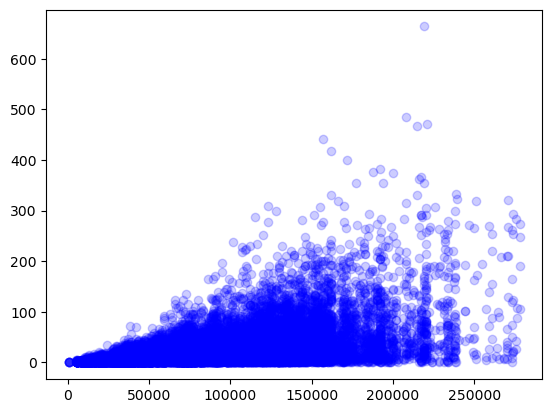

In [91]:
plot_negative_binomial(intercept=-10.31864312, beta2=2.37986E-06, beta1=1.160463401, k=1, x_values=real_adt_values)

In [81]:
nb_counts

array([ 4,  1,  6, ..., 59, 10,  4], shape=(18733,))

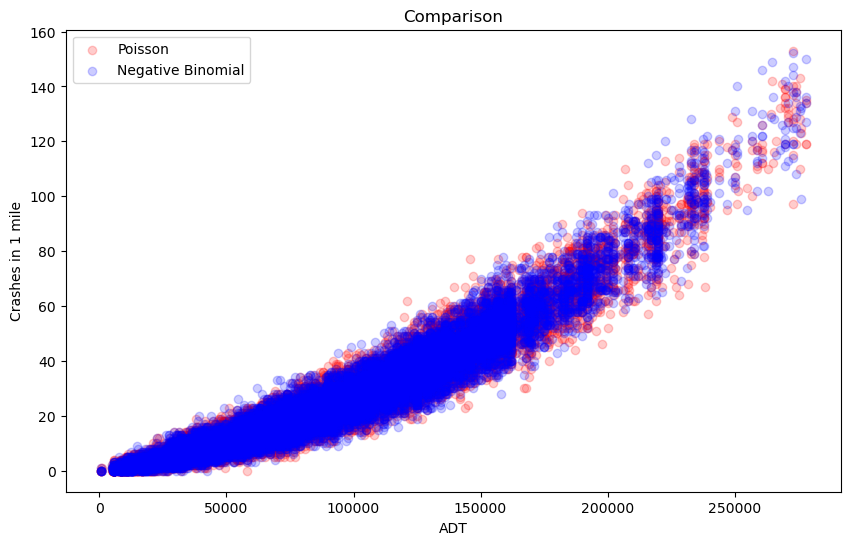

In [97]:
# Plotting
plt.figure(figsize=(10, 6))
plot_poisson(intercept=-10.31864312, beta2=2.37986E-06, beta1=1.160463401, x_values=real_adt_values)
plot_negative_binomial(intercept=-10.31864312, beta2=2.37986E-06, beta1=1.160463401, x_values=real_adt_values)
plt.xlabel('ADT')
plt.ylabel('Crashes in 1 mile')
plt.title('Comparison')
plt.legend()
plt.show()

/var/folders/zg/cbxt1xlj7rj012hws7_30d_00000gn/T/ipykernel_54981/2251498032.py:9: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(real_adt_values), np.log(actual_rate),


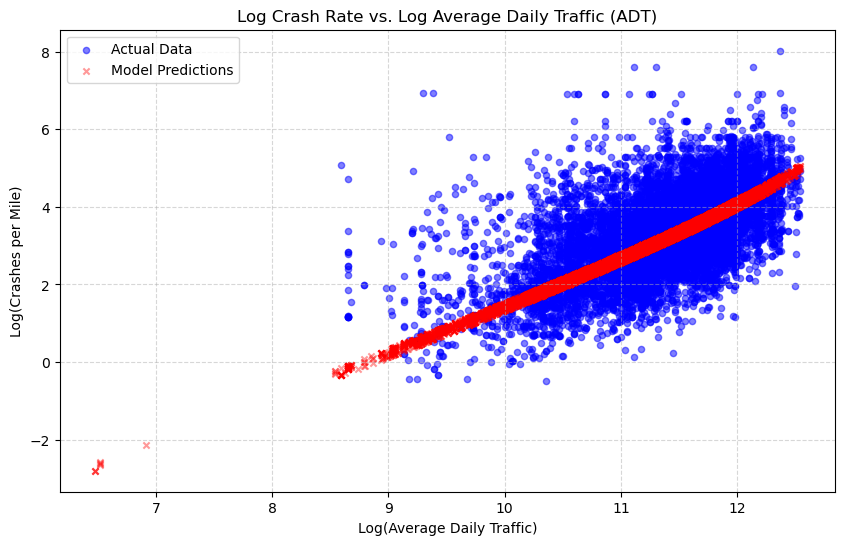

In [98]:
import matplotlib.pyplot as plt
import numpy as np

actual_rate = real_crash_counts / real_length_values
predicted_rate = model_predictions / real_length_values

plt.figure(figsize=(10, 6))

plt.scatter(np.log(real_adt_values), np.log(actual_rate), 
            alpha=0.5, color='blue', label='Actual Data', s=20)

plt.scatter(np.log(real_adt_values), np.log(predicted_rate), 
            alpha=0.4, color='red', marker='x', label='Model Predictions', s=20)

plt.title('Log Crash Rate vs. Log Average Daily Traffic (ADT)')
plt.xlabel('Log(Average Daily Traffic)')
plt.ylabel('Log(Crashes per Mile)')
plt.grid(True, linestyle='--', alpha=0.5)


plt.legend(loc='best')

plt.show()